In [21]:
from warnings import filterwarnings
filterwarnings('ignore')

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/skhar/OneDrive/Desktop/pan_india_synthetic_accidents_20000_messy.csv")

df.columns = df.columns.str.strip().str.lower()

df.drop_duplicates(inplace=True)

df.replace(-1, np.nan, inplace=True)

df.dropna(subset=["latitude", "longitude"], inplace=True)

# Drop ID-like columns
if "accident_id" in df.columns:
    df.drop(columns=["accident_id"], inplace=True)

if "random_noise_column" in df.columns:
    df.drop(columns=["random_noise_column"], inplace=True)

# Fill numeric
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# ONLY encode safe categorical columns
safe_categorical = ["weather", "traffic_density", "road_type"]

for col in safe_categorical:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

df = pd.get_dummies(df, columns=safe_categorical, drop_first=True)

print("Final Shape:", df.shape)
print("Remaining Missing:", df.isnull().sum().sum())

Final Shape: (20400, 26)
Remaining Missing: 0


In [27]:
df

,accident_id,latitude,longitude,state,zone_name,hour,day_of_week,light_condition,speed_limit,vehicles_involved,...,weather_dust,weather_fog,weather_hail,weather_overcast,weather_rain,traffic_density_low,traffic_density_medium,road_type_rural road,road_type_state highway,road_type_urban road
0,a000001,13.049344,80.280267,tamil nadu,chennai,6,mon,daylight,80.0,2,...,False,False,False,False,False,False,True,True,False,False
1,a000002,26.860652,75.770431,rajasthan,jaipur,17,tue,daylight,60.0,3,...,False,False,False,False,False,False,True,False,True,False
2,a000003,22.554581,88.355149,west bengal,kolkata,18,sat,darkness - lights lit,80.0,1,...,False,False,False,False,False,False,False,False,False,False
3,a000004,11.038954,76.960941,tamil nadu,coimbatore,4,mon,darkness - lights lit,120.0,2,...,False,False,False,False,False,False,True,False,False,False
4,a000005,28.078364,73.762755,various,rural area,0,thu,darkness - lights lit,30.0,2,...,False,False,False,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,a014901,12.979853,77.578270,karnataka,bengaluru,17,sun,daylight,100.0,2,...,False,False,False,False,False,False,True,False,True,False
20396,a011227,23.901244,76.403870,karnataka,ludhiana-bengaluru corridor,20,sat,darkness - lights lit,30.0,3,...,False,False,False,False,True,False,True,False,False,True
20397,a019133,22.294398,73.186184,gujarat,vadodara,9,fri,daylight,40.0,3,...,False,False,False,False,True,True,False,False,False,True
20398,a007921,12.960057,77.611138,karnataka,bengaluru,11,fri,daylight,120.0,3,...,False,False,False,False,True,False,True,False,False,False


In [19]:
res = df.columns
print(res)

Index(['accident_id', 'latitude', 'longitude', 'state', 'zone_name', 'hour',
       'day_of_week', 'light_condition', 'speed_limit', 'vehicles_involved',
       'injuries_count', 'fatalities_count', 'accident_severity',
       'random_noise_column', 'weather_dust', 'weather_fog', 'weather_hail',
       'weather_overcast', 'weather_rain', 'traffic_density_low',
       'traffic_density_medium', 'road_type_rural road',
       'road_type_state highway', 'road_type_urban road'],
      dtype='object')


In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/skhar/OneDrive/Desktop/pan_india_synthetic_accidents_20000_messy.csv")

df.columns = df.columns.str.strip().str.lower()

df.drop_duplicates(inplace=True)

df.replace(-1, np.nan, inplace=True)

df.dropna(subset=["latitude", "longitude"], inplace=True)

# Normalize string columns
string_cols = df.select_dtypes(include='object').columns
for col in string_cols:
    df[col] = df[col].str.strip().str.lower()

# Fill numeric
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Encode clean categorical columns
df = pd.get_dummies(df, columns=["weather", "traffic_density", "road_type"], drop_first=True)

print("Final Shape:", df.shape)

Final Shape: (20400, 24)


In [22]:
for i in df.columns:
    if df[i].dtypes==object:
        df[i].fillna(df[i].mode()[0], inplace=True)
    else:
        df[i].fillna(df[i].mean(), inplace=True)
    

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSeverity Distribution:\n", df["accident_severity"].value_counts())

Shape: (20400, 24)

Missing Values:
 accident_id                0
latitude                   0
longitude                  0
state                      0
zone_name                  0
hour                       0
day_of_week                0
light_condition            0
speed_limit                0
vehicles_involved          0
injuries_count             0
fatalities_count           0
accident_severity          0
random_noise_column        0
weather_dust               0
weather_fog                0
weather_hail               0
weather_overcast           0
weather_rain               0
traffic_density_low        0
traffic_density_medium     0
road_type_rural road       0
road_type_state highway    0
road_type_urban road       0
dtype: int64

Severity Distribution:
 accident_severity
low       7164
medium    6868
high      6368
Name: count, dtype: int64


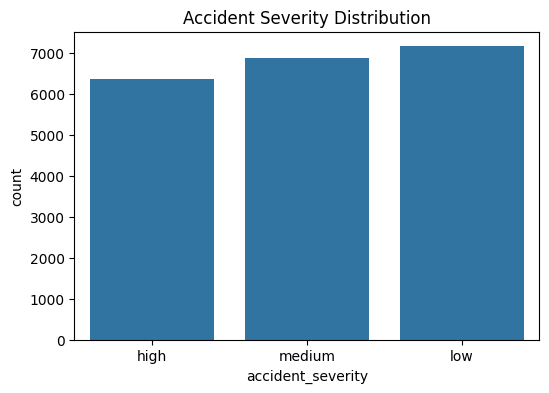

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="accident_severity")
plt.title("Accident Severity Distribution")
plt.show()

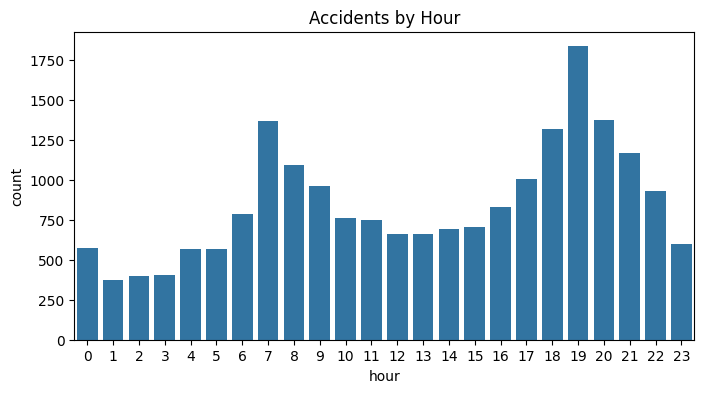

In [25]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="hour")
plt.title("Accidents by Hour")
plt.show()

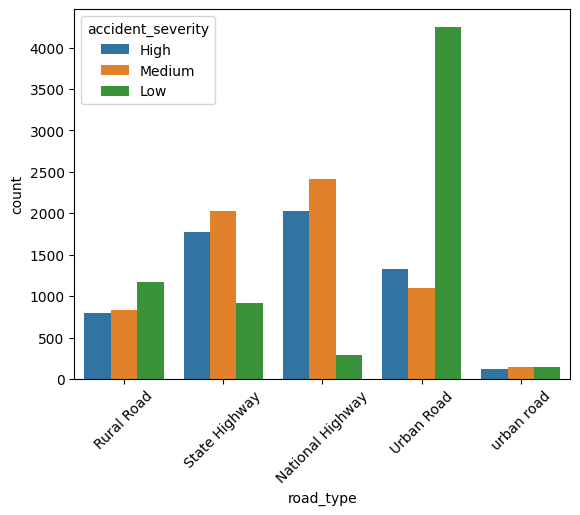

In [30]:
df_raw = pd.read_csv("C:/Users/skhar/OneDrive/Desktop/pan_india_synthetic_accidents_20000_messy.csv")

df_raw.columns = df_raw.columns.str.strip().str.lower()
sns.countplot(data=df_raw, x="road_type", hue="accident_severity")
plt.xticks(rotation=45)
plt.show()

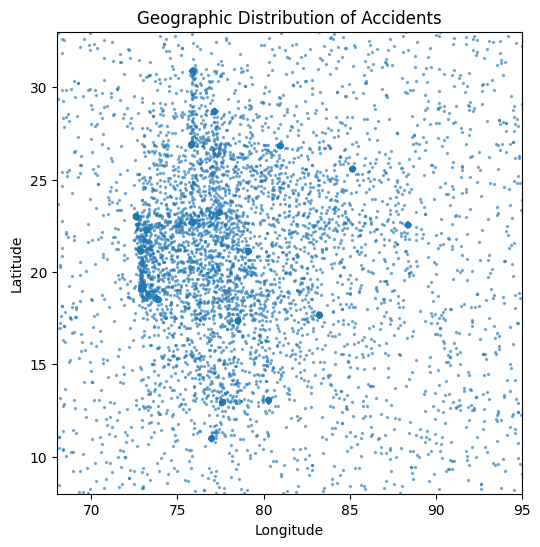

In [36]:
plt.figure(figsize=(6,6))
plt.scatter(df["longitude"], df["latitude"], s=2, alpha=0.5)
plt.xlim(68, 95)
plt.ylim(8, 33)
plt.title("Geographic Distribution of Accidents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

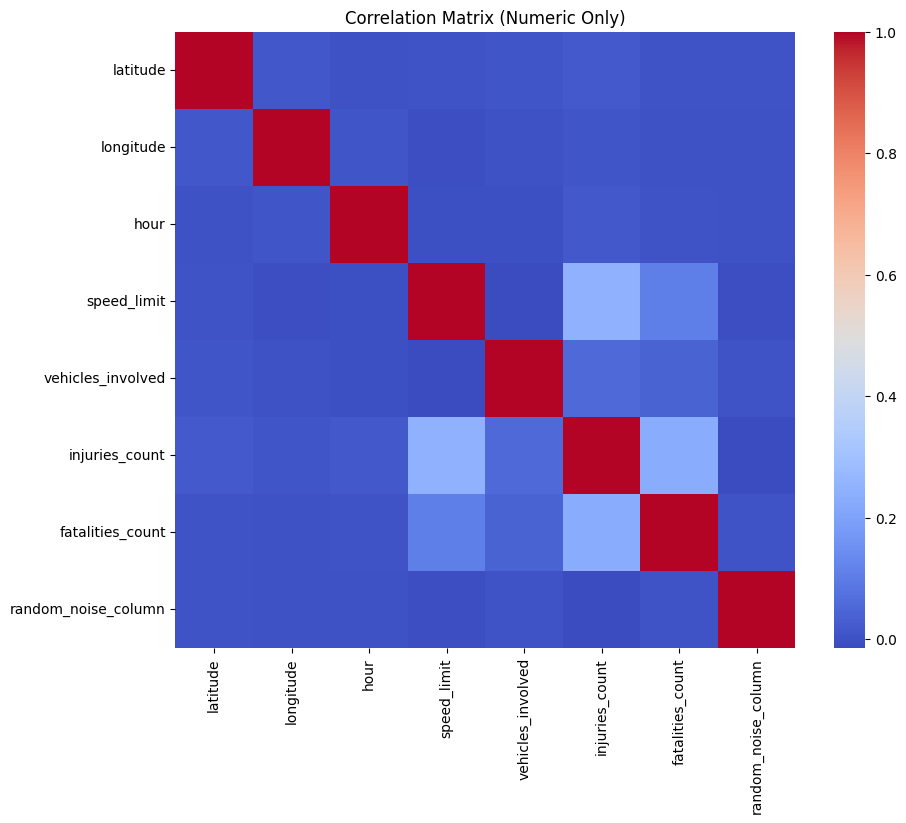

In [38]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix (Numeric Only)")
plt.show()

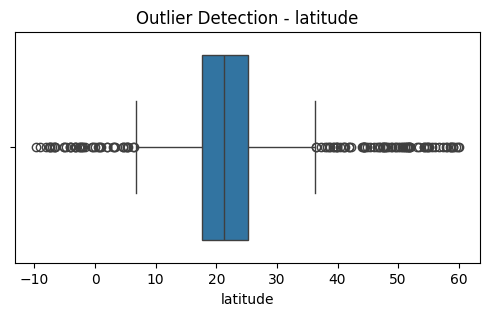

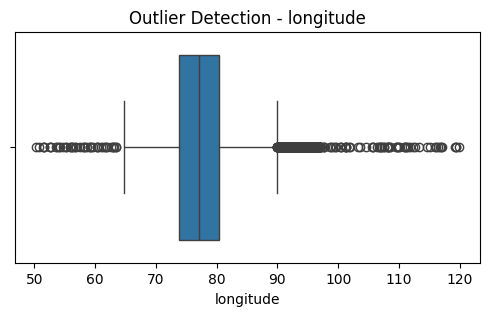

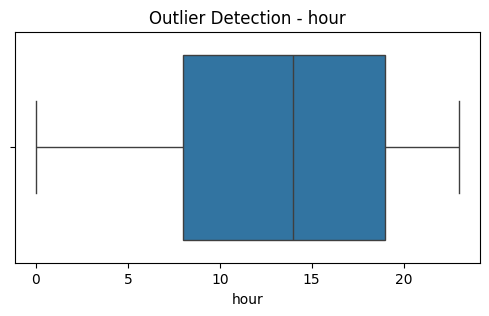

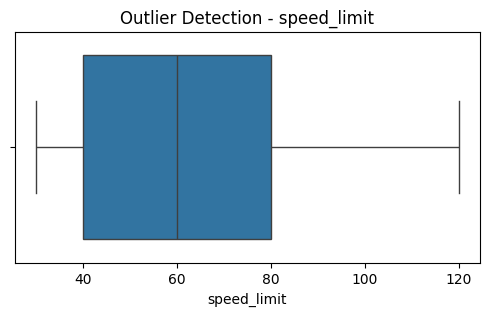

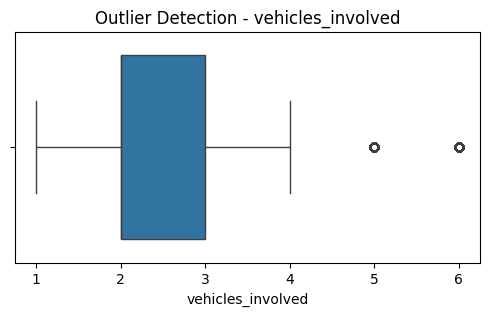

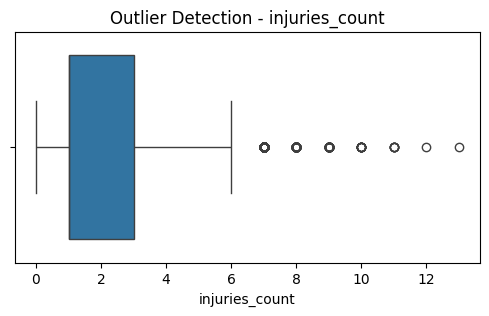

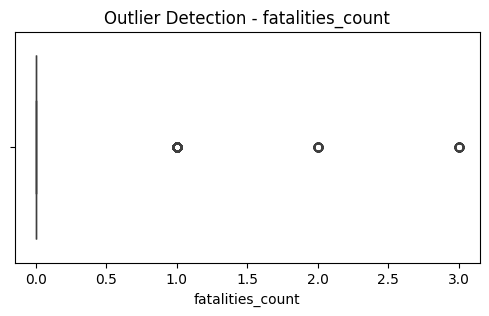

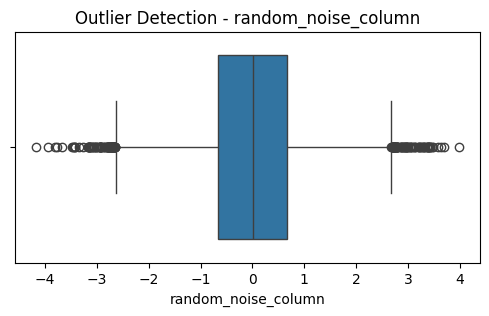

In [39]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(data=df, x=col)
    plt.title(f"Outlier Detection - {col}")
    plt.show()

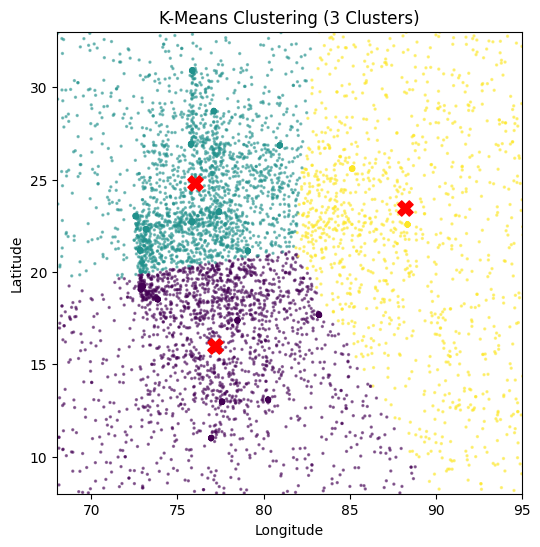

In [52]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select longitude and latitude
X = df[["longitude", "latitude"]]

# Scale data (recommended)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Convert centroids back to original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(6,6))

plt.scatter(df["longitude"], df["latitude"],
            c=df["cluster"],
            cmap="viridis",
            s=2,
            alpha=0.5)

# Plot centroids
plt.scatter(centroids[:,0], centroids[:,1],
            c="red",
            s=120,
            marker="X")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Clustering (3 Clusters)")

# ✅ Apply your limits
plt.xlim(68, 95)
plt.ylim(8, 33)

plt.show()

In [56]:
n_clusters = len(set(df["dbscan_cluster"])) - (1 if -1 in df["dbscan_cluster"].values else 0)
print("Number of clusters:", n_clusters)

Number of clusters: 26


In [59]:
gfg_csv_data = df.to_csv('cleaned.csv', index = True)

In [60]:
print('\nCSV String:\n', gfg_csv_data)


CSV String:
 None


In [61]:
df.to_csv("C:/Users/skhar/OneDrive/Desktop/Cleaned_data.csv", index=False)

In [62]:
df.groupby('level')[['longitude','latitude']].mean()

,longitude,latitude
level,,
High,80.723207,26.006419
Low,80.291051,14.423070
Medium,73.601205,21.009208


In [64]:
from sklearn.metrics import silhouette_score

score = silhouette_score(df[['longitude','latitude']], df['cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.3854167128654375


In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['longitude', 'latitude']])

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, labels)
print("New Silhouette Score:", score)

New Silhouette Score: 0.39377757645405415


In [66]:
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Score={score}")

K=2, Score=0.3265809008454367
K=3, Score=0.39377757645405415
K=4, Score=0.4692124348691745
K=5, Score=0.4669607465678021
K=6, Score=0.48806097663462694
K=7, Score=0.48685040857799705


In [67]:
kmeans = KMeans(n_clusters=6, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

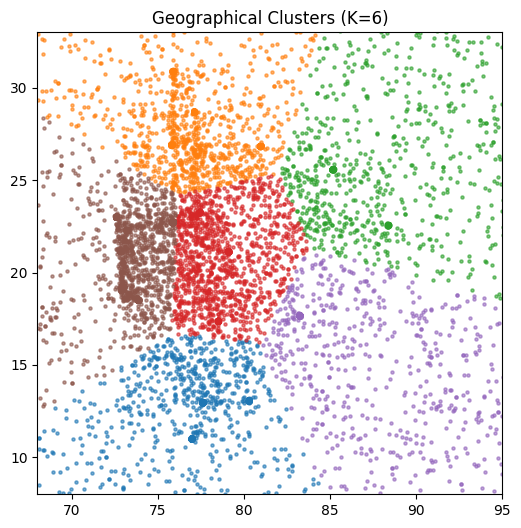

In [68]:
plt.figure(figsize=(6,6))

for i in range(6):
    subset = df[df['cluster'] == i]
    plt.scatter(subset["longitude"], subset["latitude"], s=5, alpha=0.6)

plt.xlim(68, 95)
plt.ylim(8, 33)
plt.title("Geographical Clusters (K=6)")
plt.show()

In [69]:
df.groupby('cluster')[['longitude','latitude']].mean()

,longitude,latitude
cluster,,
0,77.836000,12.336277
1,77.161854,28.506454
2,87.813212,24.998316
3,78.499769,20.612117
4,85.760828,16.246584
5,73.416766,20.865610


In [70]:
df['cluster'].value_counts()

cluster
5    6244
1    3974
3    3443
0    2953
2    2301
4    1485
Name: count, dtype: int64

In [71]:
df['cluster'].value_counts(normalize=True) * 100

cluster
5    30.607843
1    19.480392
3    16.877451
0    14.475490
2    11.279412
4     7.279412
Name: proportion, dtype: float64

In [72]:
df.groupby('cluster')[['longitude','latitude']].mean()

,longitude,latitude
cluster,,
0,77.836000,12.336277
1,77.161854,28.506454
2,87.813212,24.998316
3,78.499769,20.612117
4,85.760828,16.246584
5,73.416766,20.865610


In [73]:
df.groupby('cluster')['fatalities_count'].sum().sort_values(ascending=False)

cluster
5    771
1    487
3    413
0    374
2    296
4    152
Name: fatalities_count, dtype: int64

In [74]:
df.groupby('cluster')['injuries_count'].mean()

cluster
0    1.783610
1    1.894313
2    1.904824
3    1.835608
4    1.868013
5    1.861307
Name: injuries_count, dtype: float64

In [75]:
df.groupby(['cluster','hour']).size().unstack().fillna(0)

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cluster,,,,,,,,,,,,,,,,,,,,,
0,85,55,56,48,99,79,103,188,142,143,...,112,91,127,141,210,255,213,166,133,77
1,101,75,81,73,106,130,169,246,222,196,...,130,132,154,216,252,353,279,225,176,133
2,70,46,50,50,56,63,70,158,132,100,...,81,86,97,110,141,202,140,137,99,76
3,95,57,53,76,101,89,133,253,186,169,...,120,124,140,147,218,317,237,216,161,93
4,33,21,32,29,40,36,52,108,81,64,...,50,54,58,64,100,145,107,107,72,28
5,190,121,126,126,165,170,262,413,331,290,...,202,218,255,327,401,564,397,320,291,193


In [76]:
weather_cols = [
    'weather_rain',
    'weather_fog',
    'weather_dust',
    'weather_overcast'
]

df.groupby('cluster')[weather_cols].mean()

,weather_rain,weather_fog,weather_dust,weather_overcast
cluster,,,,
0,0.249238,0.054182,0.047071,0.036234
1,0.228737,0.042275,0.048566,0.035984
2,0.231638,0.049978,0.047805,0.040852
3,0.236712,0.049666,0.043276,0.033692
4,0.239731,0.040404,0.046465,0.035690
5,0.254644,0.049167,0.048206,0.034593


In [77]:
road_cols = [
    'road_type_rural road',
    'road_type_state highway',
    'road_type_urban road'
]

df.groupby('cluster')[road_cols].mean()

,road_type_rural road,road_type_state highway,road_type_urban road
cluster,,,
0,0.147985,0.218083,0.348459
1,0.132360,0.236286,0.349774
2,0.147327,0.224250,0.354628
3,0.135057,0.230903,0.348533
4,0.145455,0.239057,0.343434
5,0.131807,0.236707,0.342409


In [78]:
traffic_cols = [
    'traffic_density_low',
    'traffic_density_medium'
]

df.groupby('cluster')[traffic_cols].mean()

,traffic_density_low,traffic_density_medium
cluster,,
0,0.184219,0.469015
1,0.189733,0.453951
2,0.263364,0.424598
3,0.180366,0.444089
4,0.309764,0.386532
5,0.159353,0.471012


In [79]:
summary = df.groupby('cluster').agg({
    'accident_id':'count',
    'fatalities_count':'sum',
    'injuries_count':'mean',
    'vehicles_involved':'mean',
    'speed_limit':'mean'
})

print(summary)

         accident_id  fatalities_count  injuries_count  vehicles_involved  \
cluster                                                                     
0               2953               374        1.783610           2.390789   
1               3974               487        1.894313           2.422999   
2               2301               296        1.904824           2.380704   
3               3443               413        1.835608           2.395585   
4               1485               152        1.868013           2.416835   
5               6244               771        1.861307           2.407431   

         speed_limit  
cluster               
0          66.986116  
1          67.209361  
2          67.049109  
3          67.932036  
4          67.730640  
5          68.106983  


In [80]:
df.groupby('cluster').agg({
    'accident_id':'count',
    'fatalities_count':'sum',
    'injuries_count':'mean',
    'speed_limit':'mean',
    'vehicles_involved':'mean'
}).sort_values(by='accident_id', ascending=False)

,accident_id,fatalities_count,injuries_count,speed_limit,vehicles_involved
cluster,,,,,
5,6244,771,1.861307,68.106983,2.407431
1,3974,487,1.894313,67.209361,2.422999
3,3443,413,1.835608,67.932036,2.395585
0,2953,374,1.783610,66.986116,2.390789
2,2301,296,1.904824,67.049109,2.380704
4,1485,152,1.868013,67.730640,2.416835


In [81]:
df.groupby('cluster')['fatalities_count'].sum().sort_values(ascending=False)

cluster
5    771
1    487
3    413
0    374
2    296
4    152
Name: fatalities_count, dtype: int64

In [82]:
df.groupby(['cluster','hour']).size()

cluster  hour
0        0        85
         1        55
         2        56
         3        48
         4        99
                ... 
5        19      564
         20      397
         21      320
         22      291
         23      193
Length: 144, dtype: int64

In [83]:
df.groupby('cluster')[[
    'road_type_rural road',
    'road_type_state highway',
    'road_type_urban road'
]].mean()

,road_type_rural road,road_type_state highway,road_type_urban road
cluster,,,
0,0.147985,0.218083,0.348459
1,0.132360,0.236286,0.349774
2,0.147327,0.224250,0.354628
3,0.135057,0.230903,0.348533
4,0.145455,0.239057,0.343434
5,0.131807,0.236707,0.342409


In [84]:
summary = df.groupby('cluster').agg({
    'accident_id':'count',
    'fatalities_count':'sum',
    'injuries_count':'mean'
})

summary['risk_score'] = (
    0.5 * summary['fatalities_count'] +
    0.3 * summary['injuries_count'] +
    0.2 * summary['accident_id']
)

summary.sort_values(by='risk_score', ascending=False)

,accident_id,fatalities_count,injuries_count,risk_score
cluster,,,,
5,6244,771,1.861307,1634.858392
1,3974,487,1.894313,1038.868294
3,3443,413,1.835608,895.650683
0,2953,374,1.783610,778.135083
2,2301,296,1.904824,608.771447
4,1485,152,1.868013,373.560404


In [85]:
import pandas as pd
import numpy as np

# Load dataset
df_new = pd.read_csv("C:/Users/skhar/OneDrive/Desktop/Cleaned_data_with_varied_datetime.csv")

print("Shape:", df_new.shape)
print(df_new.head())

Shape: (20400, 29)
  accident_id   latitude  longitude        state   zone_name  hour  \
0     a000001  13.049344  80.280267   tamil nadu     chennai     6   
1     a000002  26.860652  75.770431    rajasthan      jaipur    17   
2     a000003  22.554581  88.355149  west bengal     kolkata    18   
3     a000004  11.038954  76.960941   tamil nadu  coimbatore     4   
4     a000005  28.078364  73.762755      various  rural area     0   

   Unnamed: 6        light_condition  speed_limit  vehicles_involved  ...  \
0         NaN               daylight           80                  2  ...   
1         NaN               daylight           60                  3  ...   
2         NaN  darkness - lights lit           80                  1  ...   
3         NaN  darkness - lights lit          120                  2  ...   
4         NaN  darkness - lights lit           30                  2  ...   

   traffic_density_low  traffic_density_medium road_type_rural road  \
0                False    

In [86]:
# Clean column names
df_new.columns = df_new.columns.str.strip().str.lower()

# Remove duplicates
df_new.drop_duplicates(inplace=True)

# Replace -1 with NaN
df_new.replace(-1, np.nan, inplace=True)

# Drop rows missing coordinates
df_new.dropna(subset=["latitude", "longitude"], inplace=True)

print("Cleaned Shape:", df_new.shape)

Cleaned Shape: (20400, 29)


In [87]:
# Drop non-model columns
drop_cols = [
    "accident_id",
    "latitude",
    "longitude",
    "state",
    "zone_name",
    "random_noise_column",
    "cluster",
    "dbscan_cluster",
    "level",
    "date"
]

X = df_new.drop(columns=[col for col in drop_cols if col in df_new.columns])
y = df_new["accident_severity"]

print("Features Shape:", X.shape)

Features Shape: (20400, 19)


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [89]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ValueError: could not convert string to float: 'darkness - lights lit'

Encoding these columns: ['state', 'zone_name', 'light_condition', 'time']
Accuracy: 0.6776960784313726

Classification Report:

              precision    recall  f1-score   support

        high       0.69      0.66      0.68      1274
         low       0.75      0.82      0.78      1433
      medium       0.58      0.55      0.56      1373

    accuracy                           0.68      4080
   macro avg       0.67      0.68      0.67      4080
weighted avg       0.67      0.68      0.67      4080



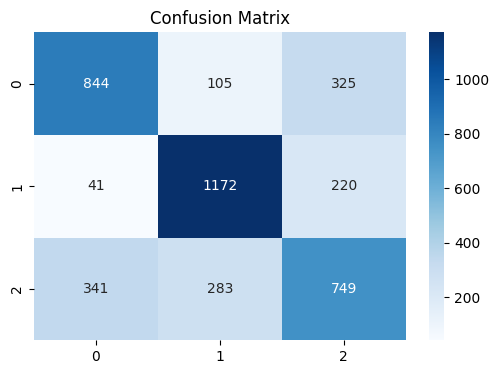

In [91]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1️⃣ COPY DATA
# ===============================
df = df_new.copy()
df.columns = df.columns.str.strip().str.lower()

# ===============================
# 2️⃣ DROP NON-MODEL COLUMNS
# ===============================
drop_cols = [
    "accident_id",
    "latitude",
    "longitude",
    "random_noise_column",
    "cluster",
    "dbscan_cluster",
    "level",
    "date"
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# ===============================
# 3️⃣ SEPARATE TARGET FIRST
# ===============================
y = df["accident_severity"]

X = df.drop("accident_severity", axis=1)

# ===============================
# 4️⃣ ENCODE ONLY FEATURES
# ===============================
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print("Encoding these columns:", categorical_cols)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ===============================
# 5️⃣ TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# 6️⃣ TRAIN MODEL
# ===============================
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# ===============================
# 7️⃣ EVALUATE
# ===============================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [92]:
df

,state,zone_name,hour,unnamed: 6,light_condition,speed_limit,vehicles_involved,injuries_count,fatalities_count,accident_severity,...,weather_fog,weather_hail,weather_overcast,weather_rain,traffic_density_low,traffic_density_medium,road_type_rural road,road_type_state highway,road_type_urban road,time
0,tamil nadu,chennai,6,NaN,daylight,80,2,3,0,high,...,False,False,False,False,False,True,True,False,False,Morning
1,rajasthan,jaipur,17,NaN,daylight,60,3,1,0,medium,...,False,False,False,False,False,True,False,True,False,Evening
2,west bengal,kolkata,18,NaN,darkness - lights lit,80,1,3,0,high,...,False,False,False,False,False,False,False,False,False,Night
3,tamil nadu,coimbatore,4,NaN,darkness - lights lit,120,2,3,1,high,...,False,False,False,False,False,True,False,False,False,Morning
4,various,rural area,0,NaN,darkness - lights lit,30,2,0,0,low,...,False,False,False,True,False,True,False,False,True,Evening
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,karnataka,bengaluru,17,NaN,daylight,100,2,1,0,medium,...,False,False,False,False,False,True,False,True,False,Night
20396,karnataka,ludhiana-bengaluru corridor,20,NaN,darkness - lights lit,30,3,2,0,high,...,False,False,False,True,False,True,False,False,True,Afternoon
20397,gujarat,vadodara,9,NaN,daylight,40,3,2,0,medium,...,False,False,False,True,True,False,False,False,True,Evening
20398,karnataka,bengaluru,11,NaN,daylight,120,3,4,0,high,...,False,False,False,True,False,True,False,False,False,Afternoon


In [93]:
# Remove garbage and leakage columns
drop_cols = [
    "state",
    "zone_name",
    "unnamed: 6",
    "time"
]

df = df_new.copy()
df.columns = df.columns.str.strip().str.lower()

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Separate target
y = df["accident_severity"]
X = df.drop("accident_severity", axis=1)

# Encode only remaining object columns
categorical_cols = X.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

Encoding: ['accident_id', 'light_condition', 'level', 'date']
Accuracy: 0.633578431372549

Classification Report:

              precision    recall  f1-score   support

        high       0.68      0.57      0.62      1274
         low       0.67      0.76      0.71      1433
      medium       0.55      0.56      0.56      1373

    accuracy                           0.63      4080
   macro avg       0.64      0.63      0.63      4080
weighted avg       0.63      0.63      0.63      4080



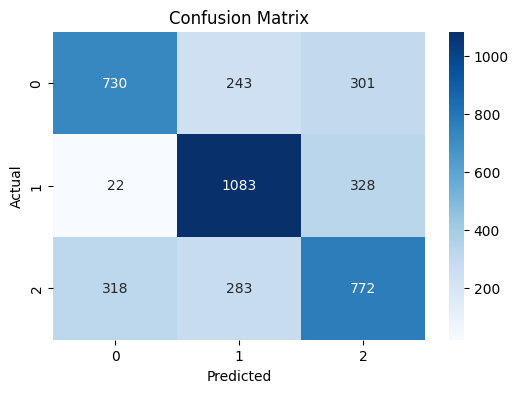

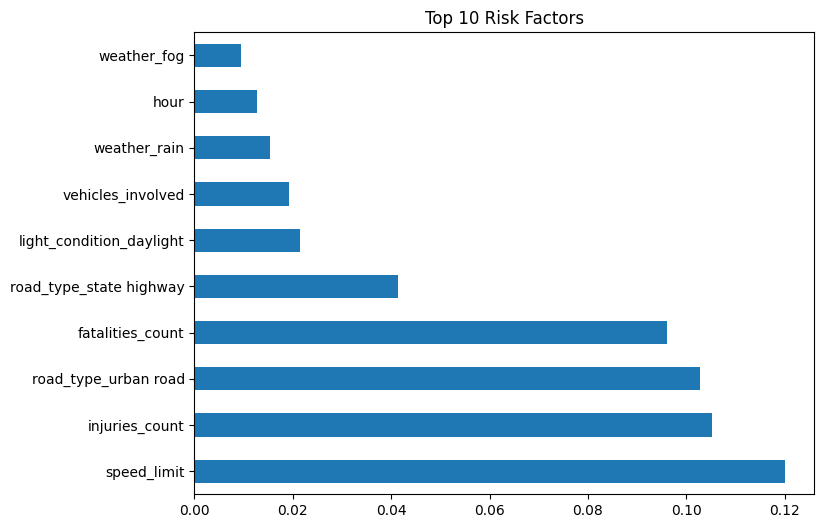


Top 10 Important Features:
speed_limit                 0.120041
injuries_count              0.105221
road_type_urban road        0.102673
fatalities_count            0.096074
road_type_state highway     0.041437
light_condition_daylight    0.021517
vehicles_involved           0.019207
weather_rain                0.015406
hour                        0.012629
weather_fog                 0.009470
dtype: float64


In [94]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1️⃣ LOAD DATA
# ===============================
df = df_new.copy()
df.columns = df.columns.str.strip().str.lower()

# ===============================
# 2️⃣ DROP USELESS / NOISE COLUMNS
# ===============================
drop_cols = [
    "state",
    "zone_name",
    "unnamed: 6",
    "time"
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# ===============================
# 3️⃣ SEPARATE TARGET
# ===============================
y = df["accident_severity"]
X = df.drop("accident_severity", axis=1)

# ===============================
# 4️⃣ ENCODE CATEGORICAL FEATURES
# ===============================
categorical_cols = X.select_dtypes(include="object").columns.tolist()

print("Encoding:", categorical_cols)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ===============================
# 5️⃣ TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# 6️⃣ TRAIN IMPROVED RANDOM FOREST
# ===============================
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# ===============================
# 7️⃣ EVALUATION
# ===============================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt="d",
            cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 8️⃣ FEATURE IMPORTANCE
# ===============================
importance = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,6))
importance.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Risk Factors")
plt.show()

print("\nTop 10 Important Features:")
print(importance.sort_values(ascending=False).head(10))

Encoding only: ['light_condition']
Accuracy: 0.6894607843137255

Classification Report:

              precision    recall  f1-score   support

        high       0.69      0.67      0.68      1274
         low       0.77      0.83      0.80      1433
      medium       0.59      0.56      0.57      1373

    accuracy                           0.69      4080
   macro avg       0.68      0.69      0.69      4080
weighted avg       0.69      0.69      0.69      4080



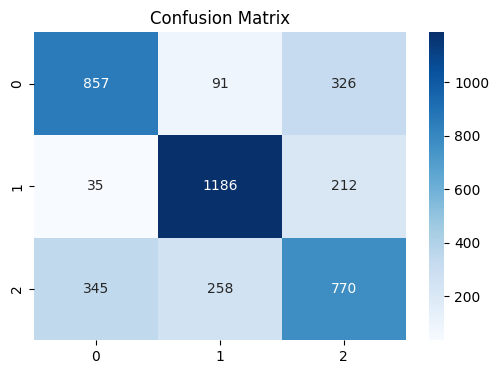


Top 10 Important Features:
injuries_count          0.232207
speed_limit             0.117132
random_noise_column     0.102491
latitude                0.099820
longitude               0.099443
fatalities_count        0.070556
hour                    0.069673
road_type_urban road    0.044839
vehicles_involved       0.039777
cluster                 0.019617
dtype: float64


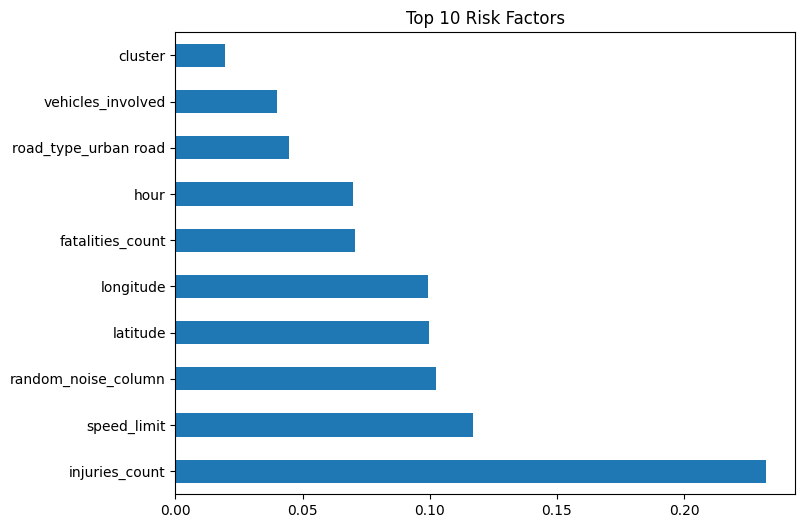

In [95]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1️⃣ CLEAN DATA
# ===============================
df = df_new.copy()
df.columns = df.columns.str.strip().str.lower()

# Drop unwanted columns
drop_cols = [
    "accident_id",
    "state",
    "zone_name",
    "unnamed: 6",
    "level",
    "date",
    "time"
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# ===============================
# 2️⃣ TARGET & FEATURES
# ===============================
y = df["accident_severity"]
X = df.drop("accident_severity", axis=1)

# ===============================
# 3️⃣ ENCODE CATEGORICAL FEATURES
# ===============================
categorical_cols = X.select_dtypes(include="object").columns.tolist()

print("Encoding only:", categorical_cols)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ===============================
# 4️⃣ SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# 5️⃣ TRAIN IMPROVED RF
# ===============================
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=4,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# ===============================
# 6️⃣ EVALUATE
# ===============================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt="d",
            cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# 7️⃣ FEATURE IMPORTANCE
# ===============================
importance = pd.Series(model.feature_importances_, index=X.columns)

print("\nTop 10 Important Features:")
print(importance.sort_values(ascending=False).head(10))

plt.figure(figsize=(8,6))
importance.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Risk Factors")
plt.show()

In [96]:
df = df_new.copy()
df.columns = df.columns.str.strip().str.lower()

# Drop non-generalizable columns
drop_cols = [
    "accident_id",
    "state",
    "zone_name",
    "unnamed: 6",
    "level",
    "date",
    "time",
    "random_noise_column",
    "latitude",
    "longitude",
    "cluster",
    "dbscan_cluster"
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Separate target
y = df["accident_severity"]
X = df.drop("accident_severity", axis=1)

# Encode categorical
categorical_cols = X.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=4,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import classification_report, accuracy_score
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6740196078431373
              precision    recall  f1-score   support

        high       0.67      0.67      0.67      1274
         low       0.77      0.79      0.78      1433
      medium       0.57      0.55      0.56      1373

    accuracy                           0.67      4080
   macro avg       0.67      0.67      0.67      4080
weighted avg       0.67      0.67      0.67      4080



In [98]:
import pandas as pd
import numpy as np

df = df_new.copy()
df.columns = df.columns.str.strip().str.lower()

# Keep only UI-relevant columns
columns_needed = [
    "hour",
    "light_condition",
    "weather_dust",
    "weather_fog",
    "weather_hail",
    "weather_overcast",
    "weather_rain",
    "traffic_density_low",
    "traffic_density_medium",
    "road_type_rural road",
    "road_type_state highway",
    "road_type_urban road",
    "accident_severity"
]

df = df[columns_needed]

In [99]:
from sklearn.model_selection import train_test_split

y = df["accident_severity"]
X = df.drop("accident_severity", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [102]:
import pandas as pd
import numpy as np

df = df_new.copy()
df.columns = df.columns.str.strip().str.lower()

# Keep only UI relevant columns
columns_needed = [
    "hour",
    "light_condition",
    "weather_dust",
    "weather_fog",
    "weather_hail",
    "weather_overcast",
    "weather_rain",
    "traffic_density_low",
    "traffic_density_medium",
    "road_type_rural road",
    "road_type_state highway",
    "road_type_urban road",
    "accident_severity"
]

df = df[columns_needed]

# 🔥 Convert light_condition to binary
df["light_condition"] = df["light_condition"].str.lower()
df["light_condition"] = df["light_condition"].apply(
    lambda x: 1 if "darkness - lights lit" in x else 0
)

# Split
from sklearn.model_selection import train_test_split

y = df["accident_severity"]
X = df.drop("accident_severity", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train
from sklearn.ensemble import RandomForestClassifier

model_ui = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced"
)

model_ui.fit(X_train, y_train)

print("UI Model Accuracy:", model_ui.score(X_test, y_test))

UI Model Accuracy: 0.4818627450980392


In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score

In [104]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=300),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

In [105]:
results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1
    }

# Display results
for model_name, metrics in results.items():
    print(f"\n{model_name}")
    print("Accuracy:", round(metrics["Accuracy"], 4))
    print("F1 Score:", round(metrics["F1 Score"], 4))


Logistic Regression
Accuracy: 0.5037
F1 Score: 0.4221

Decision Tree
Accuracy: 0.4816
F1 Score: 0.4766

Random Forest
Accuracy: 0.4833
F1 Score: 0.4726

Gradient Boosting
Accuracy: 0.4973
F1 Score: 0.4358

KNN
Accuracy: 0.4517
F1 Score: 0.4517

SVM
Accuracy: 0.5054
F1 Score: 0.4133
